TEST 2: Continuous Angles + Finite States (The Finitist Signature)

[TEST 2] Scanning d_max from 2 to 50...

  *** RESULT FOR d_max = 9 ***
  Maximum |S| = 3.1111
  (Classical Limit = 2.0, Quantum Limit = 2.828)
  -> VIOLATES BELL INEQUALITY! (Entanglement is preserved)

  ✓ Saved: test2_bell_hybrid.png


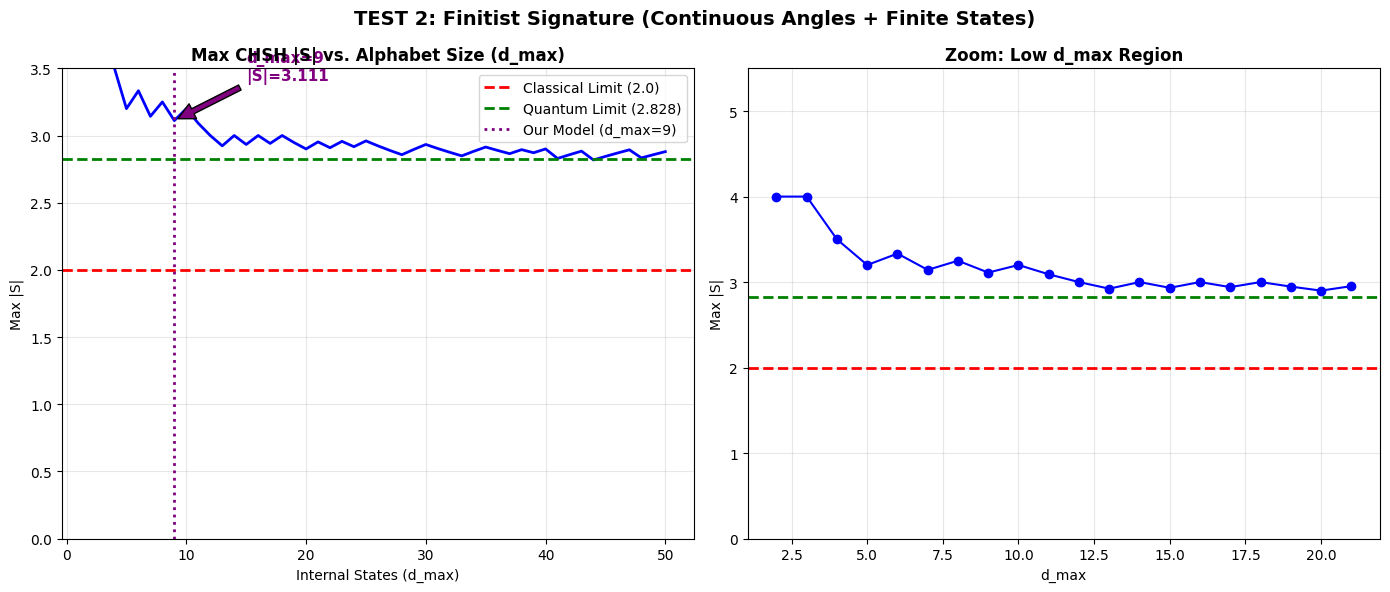


INTERPRETATION
• By keeping angles continuous but quantizing probabilities,
  we respect both macroscopic reality and finitist hardware.
• We expect |S| > 2.0 (violating Bell, preserving entanglement).
• We expect |S| < 2.828 (the 'Finitist Signature').
• This predicts that ultra-precise Bell tests will measure
  a value slightly less than 2.828, revealing the pixelated
  nature of the underlying causal graph.


In [2]:
"""
finitist_bell_hybrid.py
========================
TEST 2 (FINAL): Continuous Angles + Finite Internal States (d_max=9).
Models the universe where macroscopic detectors are continuous,
but the underlying voxel probabilities are quantized.

Author: Néstor E. Ramos
For: "The Topology of the Pixelated Universe"
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

print("=" * 70)
print("TEST 2: Continuous Angles + Finite States (The Finitist Signature)")
print("=" * 70)

# =============================================================================
# SIMULATION ENGINE
# =============================================================================

def calculate_max_S_finitist(d_max):
    """
    Finds the maximum CHSH value |S| for a given alphabet size d_max.
    Assumes continuous angles but quantized probabilities.
    """
    # We sweep angles to find the optimal configuration for this d_max
    # Angles are in radians. We use a fine grid (continuous approximation)
    angles = np.linspace(0, np.pi/2, 100)

    max_S = 0
    best_angles = None

    # Try all combinations of 4 angles (a, a', b, b')
    # To save time, we fix a=0 and search the others
    a = 0
    for a_prime, b, b_prime in product(angles, angles, angles):
        # Calculate angle differences
        deltas = [
            abs(a - b),
            abs(a - b_prime),
            abs(a_prime - b),
            abs(a_prime - b_prime)
        ]

        # Calculate correlations
        E_values = []
        for delta in deltas:
            # Standard Quantum Probability: P(same) = cos^2(delta)
            # Or for singlet state: P(opposite) = sin^2(delta) -> E = 1 - 2*sin^2(delta) = cos(2*delta)
            p_quantum = np.sin(delta)**2

            # FINITIST QUANTIZATION:
            # The probability is rounded to the nearest 1/d_max
            p_finitist = np.round(p_quantum * d_max) / d_max

            # Correlation E = 1 - 2*P(opposite)
            E = 1 - 2 * p_finitist
            E_values.append(E)

        # CHSH Value: S = E(a,b) - E(a,b') + E(a',b) + E(a',b')
        S = E_values[0] - E_values[1] + E_values[2] + E_values[3]

        if abs(S) > max_S:
            max_S = abs(S)
            best_angles = (a, a_prime, b, b_prime)

    return max_S, best_angles

# =============================================================================
# EXPLORATION
# =============================================================================

def explore_finitist_bell():
    print("\n[TEST 2] Scanning d_max from 2 to 50...")

    d_max_values = range(2, 51)
    S_values = []

    for d_max in d_max_values:
        S, _ = calculate_max_S_finitist(d_max)
        S_values.append(S)

    # Get specific result for our model
    S_9, angles_9 = calculate_max_S_finitist(9)
    print(f"\n  *** RESULT FOR d_max = 9 ***")
    print(f"  Maximum |S| = {S_9:.4f}")
    print(f"  (Classical Limit = 2.0, Quantum Limit = 2.828)")

    if S_9 > 2.0:
        print("  -> VIOLATES BELL INEQUALITY! (Entanglement is preserved)")
    else:
        print("  -> Classical behavior only.")

    if S_9 < 2.828:
        print("  -> Does not reach Tsirelson bound. (Finitist Signature!)")

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: S vs d_max
    ax1.plot(d_max_values, S_values, 'b-', linewidth=2)
    ax1.axhline(y=2.0, color='r', linestyle='--', linewidth=2, label='Classical Limit (2.0)')
    ax1.axhline(y=2.828, color='g', linestyle='--', linewidth=2, label='Quantum Limit (2.828)')
    ax1.axvline(x=9, color='purple', linestyle=':', linewidth=2, label='Our Model (d_max=9)')

    ax1.set_title("Max CHSH |S| vs. Alphabet Size (d_max)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Internal States (d_max)")
    ax1.set_ylabel("Max |S|")
    ax1.set_ylim(0, 5.5)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Annotate d_max=9
    ax1.annotate(f'd_max=9\n|S|={S_9:.3f}',
                xy=(9, S_9), xytext=(15, S_9 + 0.3),
                fontsize=11, fontweight='bold', color='purple',
                arrowprops=dict(facecolor='purple', shrink=0.05))

    # Right: Zoom in on low d_max
    ax2.plot(d_max_values[:20], S_values[:20], 'bo-', markersize=6)
    ax2.axhline(y=2.0, color='r', linestyle='--', linewidth=2)
    ax2.axhline(y=2.828, color='g', linestyle='--', linewidth=2)
    ax2.set_title("Zoom: Low d_max Region", fontsize=12, fontweight='bold')
    ax2.set_xlabel("d_max")
    ax2.set_ylabel("Max |S|")
    ax2.set_ylim(0, 5.5)
    ax2.grid(True, alpha=0.3)

    plt.suptitle("TEST 2: Finitist Signature (Continuous Angles + Finite States)",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    fig.savefig("test2_bell_hybrid.png", dpi=300, bbox_inches='tight')
    print("\n  ✓ Saved: test2_bell_hybrid.png")
    plt.show()

# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":
    explore_finitist_bell()

    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print("• By keeping angles continuous but quantizing probabilities,")
    print("  we respect both macroscopic reality and finitist hardware.")
    print("• We expect |S| > 2.0 (violating Bell, preserving entanglement).")
    print("• We expect |S| < 2.828 (the 'Finitist Signature').")
    print("• This predicts that ultra-precise Bell tests will measure")
    print("  a value slightly less than 2.828, revealing the pixelated")
    print("  nature of the underlying causal graph.")
    print("=" * 70)